In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import math
import glob
import re
sns.set(style='whitegrid')

In [ ]:
wid_exp = [(768, 4, 350), (512, 4, 100), (384, 8, 48),  (512, 8, 160), (512, 12, 220), (384, 4, 32),  (1024, 4, 350), (384, 4, 1)]
lrs = [0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, 0.128]
seeds = [1]
seeds = [0]
depth = 14

time = '20250926_212727'

In [3]:
results_val = {}
results_tr = {}
for lr in lrs:
    for width, num_exp, _ in wid_exp:
            num_act = int(num_exp // 4)
            for seed in seeds:
                print()
                file_name = f'../run_data/mutransfer_lr_cccc/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}/log.csv'
                if os.path.exists(file_name):
                    try:
                        csv_df = pd.read_csv(file_name)
                    except:
                        print(f"File {file_name} is corrupted, skipping")
                        results_val[(width, num_exp, num_act, seed, lr)] = 10.0
                        results_tr[(width, num_exp, num_act, seed, lr)] = 10.0
                        continue
                    val_loss = csv_df.iloc[-1]['val/loss']
                    if val_loss > 0.0:
                        avg_train_loss = np.mean(csv_df['train/loss'][-50:])
                        print(f"result found for {file_name}, val_loss achieved {val_loss}")
                        print(f"average training loss for last 50 steps: {avg_train_loss}")
                        results_val[(width, num_exp, num_act, seed, lr)] = val_loss
                        results_tr[(width, num_exp, num_act, seed, lr)] = avg_train_loss
                    else:
                        print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                        print(f"Lowest traininig loss achieved: {np.min(csv_df['train/loss'])}")
                else:
                    print(f"File {file_name} does not exist, check your path")


result found for ../run_data/mutransfer_lr_cccc/out_20250926_212727/width768_depth14_experts4_active1_seed0_lr0.001/log.csv, val_loss achieved 4.041613578796387
average training loss for last 50 steps: 4.037059783935547

result found for ../run_data/mutransfer_lr_cccc/out_20250926_212727/width512_depth14_experts4_active1_seed0_lr0.001/log.csv, val_loss achieved 4.183297634124756
average training loss for last 50 steps: 4.17983341217041

result found for ../run_data/mutransfer_lr_cccc/out_20250926_212727/width384_depth14_experts8_active2_seed0_lr0.001/log.csv, val_loss achieved 4.287278175354004
average training loss for last 50 steps: 4.287459373474121

result found for ../run_data/mutransfer_lr_cccc/out_20250926_212727/width512_depth14_experts8_active2_seed0_lr0.001/log.csv, val_loss achieved 4.143743991851807
average training loss for last 50 steps: 4.140990734100342

result found for ../run_data/mutransfer_lr_cccc/out_20250926_212727/width512_depth14_experts12_active3_seed0_lr0.001

In [4]:
def plot_results(result, title = ""):
    plt.figure(figsize=(10, 6))
    config_results = {}
    for (width, num_exp, num_act, seed, lr), mse in result.items():
        config = (num_exp, width)
        if config not in config_results:
            config_results[config] = []
        config_results[config].append((lr, mse))
    
    # Average over seeds for each configuration and lr
    averaged_results = {}
    for config, pts in config_results.items():
        lr_to_mses = {}
        for lr, mse in pts:
            if lr not in lr_to_mses:
                lr_to_mses[lr] = []
            lr_to_mses[lr].append(mse)
        
        # Average MSEs for each lr
        averaged_pts = []
        for lr in sorted(lr_to_mses.keys()):
            avg_mse = np.mean(lr_to_mses[lr])
            averaged_pts.append((lr, avg_mse))
        averaged_results[config] = averaged_pts
    
    # Count total experiments
    total_experiments = len(result)
    print(f"Total experiments: {total_experiments}")
    
    # Print summary
    print("\nResults by configuration:")
    for (n_exp, width), pts in sorted(averaged_results.items()):
        valid_pts = [(lr, mse) for lr, mse in pts if not math.isnan(mse)]
        print(f"  n={n_exp}, width={width}: {len(valid_pts)} valid lr points")
        if valid_pts:
            best_lr, best_mse = min(valid_pts, key=lambda x: x[1])
            print(f"    Best: lr={best_lr:.3e}, MSE={best_mse:.6f}")
    
    # Plot each configuration
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h']
    
    for idx, ((n_exp, width), pts) in enumerate(sorted(averaged_results.items())):
        if pts:
            # Sort by lr for proper line plotting
            pts_sorted = sorted(pts, key=lambda t: t[0])
            lrs_plot, mses = zip(*pts_sorted)
            
            # Filter out NaN values
            valid_pts = [(lr, mse) for lr, mse in zip(lrs_plot, mses) if not math.isnan(mse)]
            
            if valid_pts:
                valid_lrs, valid_mses = zip(*valid_pts)
                color = colors[idx % len(colors)]
                marker = markers[idx % len(markers)]
                num_act = int(n_exp // 4)
                plt.plot(valid_lrs, valid_mses, marker=marker, color=color,
                        label=f'n_exp={n_exp}, n_act={num_act}, width={width}', linewidth=1.5, markersize=6,
                        alpha=0.8)
                
                # Mark the best point with a star
                best_idx = np.argmin(valid_mses)
                plt.scatter(valid_lrs[best_idx], valid_mses[best_idx], 
                           s=200, color=color, marker='*', edgecolor='black', 
                           linewidth=2, zorder=10)

    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.ylim(3.0, 10.0)
    plt.xlabel(r'Learning rate', fontsize=12)
    plt.ylabel('log perplexity', fontsize=12)
    plt.title(f'Hyperparameter Transfer Results ' + title, 
              fontsize=14)
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    
    # Save plot
    plot_dir = "plots"
    os.makedirs(plot_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_name = os.path.join(plot_dir, f"hp_transfer_plot_{timestamp}.png")
    plt.savefig(plot_name, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as: {plot_name}")
    
    plt.show()
    
    return averaged_results




    return result

def find_job_file(base_path, time_dir, job_prefix):

    # Construct the search path
    search_pattern = os.path.join(base_path, time_dir, "stdout", f"{job_prefix}_*.log")

    # Find matching files
    matches = glob.glob(search_pattern)

    if not matches:
        return None, None

    # Take the first match if multiple exist
    full_path = matches[0]
    filename = os.path.basename(full_path)

    # Parse filename: job_0008_gpu7_w256_exp4_lr4.52e-02_seed0.log
    pattern = r'job_\d+_gpu\d+_w(\d+)_exp(\d+)_lr([\d.e\-+]+)_seed(\d+)\.log'
    match = re.match(pattern, filename)

    if not match:
        return filename, None

    params = {
        'width': int(match.group(1)),
        'num_exp': int(match.group(2)),
        'lr': float(match.group(3)),
        'seed': int(match.group(4))
    }

    return filename, params

Total experiments: 45

Results by configuration:
  n=4, width=512: 8 valid lr points
    Best: lr=1.600e-02, MSE=3.799937
  n=4, width=768: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.651961
  n=4, width=1024: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.554981
  n=8, width=384: 8 valid lr points
    Best: lr=1.600e-02, MSE=3.846453
  n=8, width=512: 8 valid lr points
    Best: lr=4.000e-03, MSE=3.797080
  n=12, width=512: 5 valid lr points
    Best: lr=1.600e-02, MSE=3.793722



Plot saved as: plots/hp_transfer_plot_20250928_135242.png


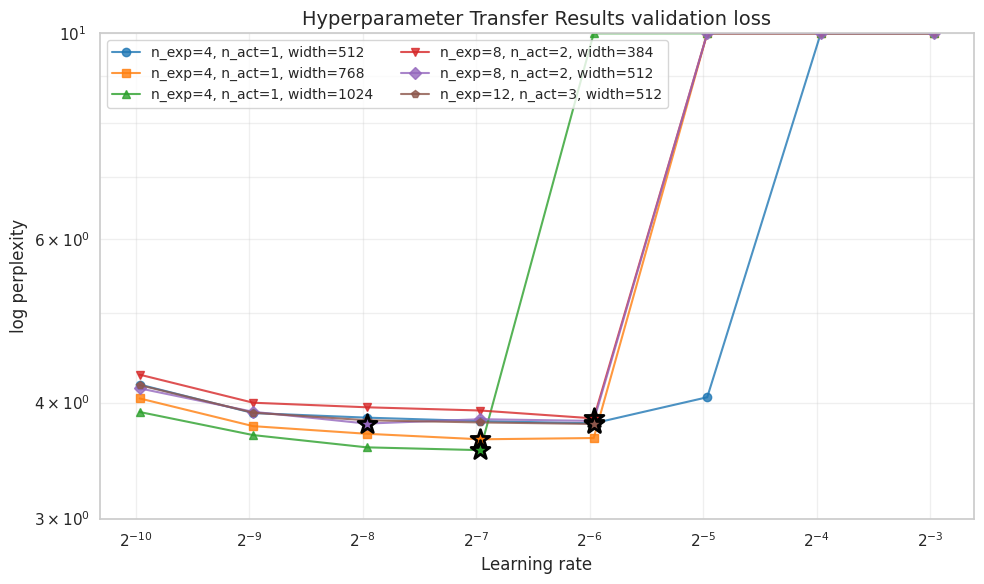

{(4, 768): [(0.001, np.float64(4.041613578796387)),
  (0.002, np.float64(3.772956132888794)),
  (0.004, np.float64(3.702325105667114)),
  (0.008, np.float64(3.651960849761963)),
  (0.016, np.float64(3.663396596908569)),
  (0.032, np.float64(10.0)),
  (0.064, np.float64(10.0)),
  (0.128, np.float64(10.0))],
 (4, 512): [(0.001, np.float64(4.183297634124756)),
  (0.002, np.float64(3.8977303504943848)),
  (0.004, np.float64(3.853501319885254)),
  (0.008, np.float64(3.8204503059387207)),
  (0.016, np.float64(3.799937248229981)),
  (0.032, np.float64(4.053595542907715)),
  (0.064, np.float64(10.0)),
  (0.128, np.float64(10.0))],
 (8, 384): [(0.001, np.float64(4.287278175354004)),
  (0.002, np.float64(3.998922348022461)),
  (0.004, np.float64(3.953923940658569)),
  (0.008, np.float64(3.922367811203003)),
  (0.016, np.float64(3.8464534282684326)),
  (0.032, np.float64(10.0)),
  (0.064, np.float64(10.0)),
  (0.128, np.float64(10.0))],
 (8, 512): [(0.001, np.float64(4.143743991851807)),
  (0.002

In [5]:
plot_results(results_val, title = "validation loss")

In [ ]:
def get_filenames_in_dir(directory_path):
      try:
          filenames = os.listdir(directory_path)
          return filenames
      except FileNotFoundError:
          print(f"Directory not found: {directory_path}")
          return []

def parse_validation_loss(log_file_path):
    result = {}
    pattern = r'Validation - step (\d+): val loss ([\d.]+)'

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    step = int(match.group(1))
                    loss = float(match.group(2))
                    result[step] = loss
    except FileNotFoundError:
        print(f"Error: File {log_file_path} not found")
        return {}
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}

In [21]:
result_complete = {}
for file_name in get_filenames_in_dir("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/"+time+"/stdout"):
    file_pwd = "/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/"+time+"/stdout/"+file_name
    if os.path.exists(file_pwd):
        pattern = r'job_\d+_gpu\d+_w(\d+)_exp(\d+)_lr([\d.e\-+]+)_seed(\d+)\.log'
        match = re.match(pattern, file_name)
        if not match:
            print(f"File {file_name} does not match the expected pattern")
        params = {
                'width': int(match.group(1)),
                'num_exp': int(match.group(2)),
                'lr': float(match.group(3)),
                'seed': int(match.group(4))
                }
        loss_dict = parse_validation_loss(file_pwd)
        width, num_exp, num_act, seed, lr = params['width'], params['num_exp'], params['num_exp']//4 , params['seed'], params['lr']
        result_complete[(width, num_exp, num_act, seed, lr)] = loss_dict
        print(f"job found, width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lr}, loss_dict {loss_dict}")
    else:
        print(f"File {file_pwd} does not exist, check your path")

job found, width 768, num_exp 4, num_act 1, seed 0, lr 0.002, loss_dict {1: 10.8336, 1001: 5.2488, 2001: 4.5336, 3001: 4.2668, 4001: 4.1109, 5001: 4.003, 6001: 3.9301, 7001: 3.8667, 8001: 3.8104, 9001: 3.7803, 10001: 3.773}
job found, width 1024, num_exp 4, num_act 1, seed 0, lr 0.128, loss_dict {1: 10.8349}
job found, width 512, num_exp 8, num_act 2, seed 0, lr 0.064, loss_dict {1: 10.8572, 1001: 4.8695}
job found, width 512, num_exp 8, num_act 2, seed 0, lr 0.032, loss_dict {1: 10.8572, 1001: 4.763, 2001: 7.4188}
job found, width 384, num_exp 8, num_act 2, seed 0, lr 0.032, loss_dict {1: 10.8636, 1001: 5.0079, 2001: 7.7042, 3001: 7.6565}
job found, width 512, num_exp 12, num_act 3, seed 0, lr 0.002, loss_dict {1: 10.8481, 1001: 5.38, 2001: 4.6801, 3001: 4.5399, 4001: 4.212, 5001: 4.1199, 6001: 4.052, 7001: 3.988, 8001: 3.9432, 9001: 3.9135, 10001: 3.9011}
job found, width 768, num_exp 4, num_act 1, seed 0, lr 0.004, loss_dict {1: 10.8336, 1001: 5.0708, 2001: 4.3525, 3001: 4.1327, 400

never reached 1001 for width 768, num_exp 4, num_act 1, seed 0, lr 0.128
never reached 1001 for width 512, num_exp 4, num_act 1, seed 0, lr 0.064
never reached 1001 for width 512, num_exp 4, num_act 1, seed 0, lr 0.128
never reached 1001 for width 384, num_exp 8, num_act 2, seed 0, lr 0.128
never reached 1001 for width 512, num_exp 8, num_act 2, seed 0, lr 0.128
never reached 1001 for width 512, num_exp 12, num_act 3, seed 0, lr 0.032
never reached 1001 for width 512, num_exp 12, num_act 3, seed 0, lr 0.064
never reached 1001 for width 512, num_exp 12, num_act 3, seed 0, lr 0.128
never reached 1001 for width 384, num_exp 4, num_act 1, seed 0, lr 0.001
never reached 1001 for width 384, num_exp 4, num_act 1, seed 0, lr 0.002
never reached 1001 for width 384, num_exp 4, num_act 1, seed 0, lr 0.004
never reached 1001 for width 384, num_exp 4, num_act 1, seed 0, lr 0.008
never reached 1001 for width 384, num_exp 4, num_act 1, seed 0, lr 0.016
never reached 1001 for width 384, num_exp 4, num


Plot saved as: plots/hp_transfer_plot_20250928_024654.png


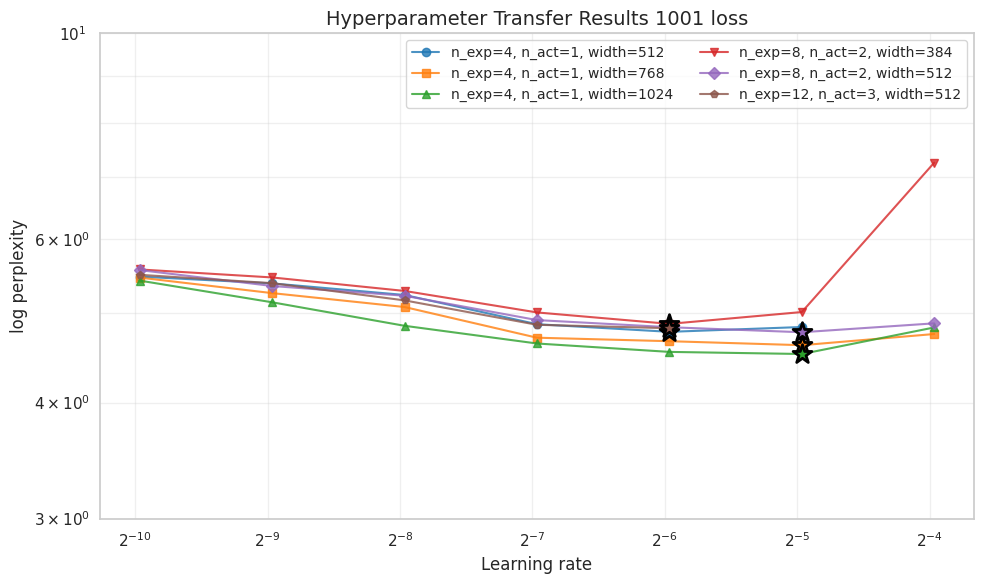

{(4, 768): [(0.001, np.float64(5.4549)),
  (0.002, np.float64(5.2488)),
  (0.004, np.float64(5.0708)),
  (0.008, np.float64(4.699)),
  (0.016, np.float64(4.6584)),
  (0.032, np.float64(4.6125)),
  (0.064, np.float64(4.7421))],
 (4, 512): [(0.001, np.float64(5.4681)),
  (0.002, np.float64(5.3768)),
  (0.004, np.float64(5.2246)),
  (0.008, np.float64(4.859)),
  (0.016, np.float64(4.7679)),
  (0.032, np.float64(4.8253))],
 (8, 384): [(0.001, np.float64(5.5661)),
  (0.002, np.float64(5.4568)),
  (0.004, np.float64(5.2771)),
  (0.008, np.float64(5.0031)),
  (0.016, np.float64(4.8629)),
  (0.032, np.float64(5.0079)),
  (0.064, np.float64(7.256))],
 (8, 512): [(0.001, np.float64(5.5573)),
  (0.002, np.float64(5.3424)),
  (0.004, np.float64(5.2146)),
  (0.008, np.float64(4.9091)),
  (0.016, np.float64(4.823)),
  (0.032, np.float64(4.763)),
  (0.064, np.float64(4.8695))],
 (12, 512): [(0.001, np.float64(5.4926)),
  (0.002, np.float64(5.38)),
  (0.004, np.float64(5.1549)),
  (0.008, np.float64(4

In [22]:
result_1001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_1001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][1001]
                except:
                    print(f"never reached 1001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results(result_1001, title = "1001 loss")


never reached 2001 for width 768, num_exp 4, num_act 1, seed 0, lr 0.064
never reached 2001 for width 768, num_exp 4, num_act 1, seed 0, lr 0.128
never reached 2001 for width 512, num_exp 4, num_act 1, seed 0, lr 0.064
never reached 2001 for width 512, num_exp 4, num_act 1, seed 0, lr 0.128
never reached 2001 for width 384, num_exp 8, num_act 2, seed 0, lr 0.064
never reached 2001 for width 384, num_exp 8, num_act 2, seed 0, lr 0.128
never reached 2001 for width 512, num_exp 8, num_act 2, seed 0, lr 0.064
never reached 2001 for width 512, num_exp 8, num_act 2, seed 0, lr 0.128
never reached 2001 for width 512, num_exp 12, num_act 3, seed 0, lr 0.032
never reached 2001 for width 512, num_exp 12, num_act 3, seed 0, lr 0.064
never reached 2001 for width 512, num_exp 12, num_act 3, seed 0, lr 0.128
never reached 2001 for width 384, num_exp 4, num_act 1, seed 0, lr 0.001
never reached 2001 for width 384, num_exp 4, num_act 1, seed 0, lr 0.002
never reached 2001 for width 384, num_exp 4, num

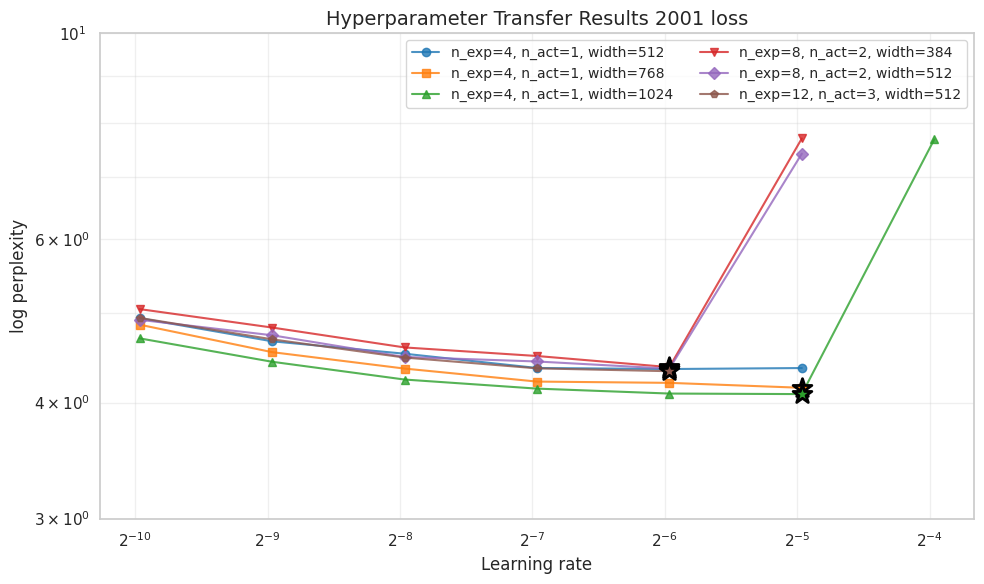

{(4, 768): [(0.001, np.float64(4.8532)),
  (0.002, np.float64(4.5336)),
  (0.004, np.float64(4.3525)),
  (0.008, np.float64(4.2143)),
  (0.016, np.float64(4.2009)),
  (0.032, np.float64(4.1498))],
 (4, 512): [(0.001, np.float64(4.9325)),
  (0.002, np.float64(4.6572)),
  (0.004, np.float64(4.516)),
  (0.008, np.float64(4.3589)),
  (0.016, np.float64(4.3475)),
  (0.032, np.float64(4.3582))],
 (8, 384): [(0.001, np.float64(5.0445)),
  (0.002, np.float64(4.819)),
  (0.004, np.float64(4.5869)),
  (0.008, np.float64(4.4904)),
  (0.016, np.float64(4.368)),
  (0.032, np.float64(7.7042))],
 (8, 512): [(0.001, np.float64(4.9124)),
  (0.002, np.float64(4.7276)),
  (0.004, np.float64(4.4798)),
  (0.008, np.float64(4.4297)),
  (0.016, np.float64(4.3515)),
  (0.032, np.float64(7.4188))],
 (12, 512): [(0.001, np.float64(4.9351)),
  (0.002, np.float64(4.6801)),
  (0.004, np.float64(4.4733)),
  (0.008, np.float64(4.3549)),
  (0.016, np.float64(4.3241))],
 (4, 1024): [(0.001, np.float64(4.6912)),
  (0.0

In [23]:
result_2001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_2001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][2001]
                except:
                    print(f"never reached 2001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results(result_2001, title = "2001 loss")

never reached 5001 for width 768, num_exp 4, num_act 1, seed 0, lr 0.064
never reached 5001 for width 768, num_exp 4, num_act 1, seed 0, lr 0.128
never reached 5001 for width 512, num_exp 4, num_act 1, seed 0, lr 0.064
never reached 5001 for width 512, num_exp 4, num_act 1, seed 0, lr 0.128
never reached 5001 for width 384, num_exp 8, num_act 2, seed 0, lr 0.032
never reached 5001 for width 384, num_exp 8, num_act 2, seed 0, lr 0.064
never reached 5001 for width 384, num_exp 8, num_act 2, seed 0, lr 0.128
never reached 5001 for width 512, num_exp 8, num_act 2, seed 0, lr 0.032
never reached 5001 for width 512, num_exp 8, num_act 2, seed 0, lr 0.064
never reached 5001 for width 512, num_exp 8, num_act 2, seed 0, lr 0.128
never reached 5001 for width 512, num_exp 12, num_act 3, seed 0, lr 0.032
never reached 5001 for width 512, num_exp 12, num_act 3, seed 0, lr 0.064
never reached 5001 for width 512, num_exp 12, num_act 3, seed 0, lr 0.128
never reached 5001 for width 384, num_exp 4, num


Plot saved as: plots/hp_transfer_plot_20250928_024739.png


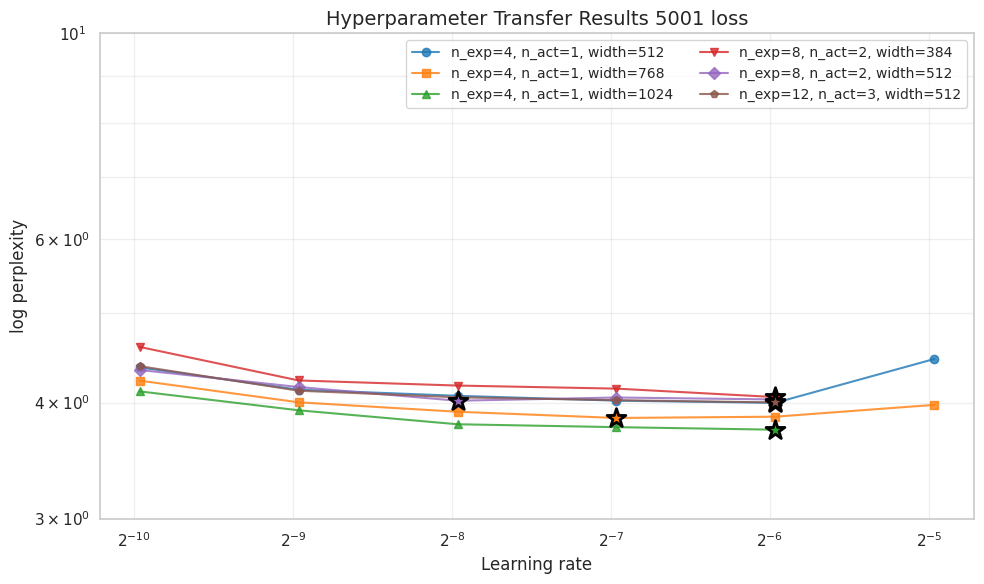

{(4, 768): [(0.001, np.float64(4.2242)),
  (0.002, np.float64(4.003)),
  (0.004, np.float64(3.9103)),
  (0.008, np.float64(3.8504)),
  (0.016, np.float64(3.8627)),
  (0.032, np.float64(3.9777))],
 (4, 512): [(0.001, np.float64(4.3651)),
  (0.002, np.float64(4.1303)),
  (0.004, np.float64(4.0683)),
  (0.008, np.float64(4.0196)),
  (0.016, np.float64(3.998)),
  (0.032, np.float64(4.4571))],
 (8, 384): [(0.001, np.float64(4.5928)),
  (0.002, np.float64(4.2261)),
  (0.004, np.float64(4.1728)),
  (0.008, np.float64(4.1413)),
  (0.016, np.float64(4.0553))],
 (8, 512): [(0.001, np.float64(4.3373)),
  (0.002, np.float64(4.1578)),
  (0.004, np.float64(4.0186)),
  (0.008, np.float64(4.051)),
  (0.016, np.float64(4.0315))],
 (12, 512): [(0.001, np.float64(4.3786)),
  (0.002, np.float64(4.1199)),
  (0.004, np.float64(4.053)),
  (0.008, np.float64(4.0241)),
  (0.016, np.float64(4.0016))],
 (4, 1024): [(0.001, np.float64(4.1128)),
  (0.002, np.float64(3.9245)),
  (0.004, np.float64(3.7908)),
  (0.00

In [25]:
result_5001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_5001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][5001]
                except:
                    print(f"never reached 5001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results(result_5001, title = "5001 loss")

never reached 8001 for width 768, num_exp 4, num_act 1, seed 0, lr 0.032
never reached 8001 for width 768, num_exp 4, num_act 1, seed 0, lr 0.064
never reached 8001 for width 768, num_exp 4, num_act 1, seed 0, lr 0.128
never reached 8001 for width 512, num_exp 4, num_act 1, seed 0, lr 0.064
never reached 8001 for width 512, num_exp 4, num_act 1, seed 0, lr 0.128
never reached 8001 for width 384, num_exp 8, num_act 2, seed 0, lr 0.032
never reached 8001 for width 384, num_exp 8, num_act 2, seed 0, lr 0.064
never reached 8001 for width 384, num_exp 8, num_act 2, seed 0, lr 0.128
never reached 8001 for width 512, num_exp 8, num_act 2, seed 0, lr 0.032
never reached 8001 for width 512, num_exp 8, num_act 2, seed 0, lr 0.064
never reached 8001 for width 512, num_exp 8, num_act 2, seed 0, lr 0.128
never reached 8001 for width 512, num_exp 12, num_act 3, seed 0, lr 0.032
never reached 8001 for width 512, num_exp 12, num_act 3, seed 0, lr 0.064
never reached 8001 for width 512, num_exp 12, num


Plot saved as: plots/hp_transfer_plot_20250928_024756.png


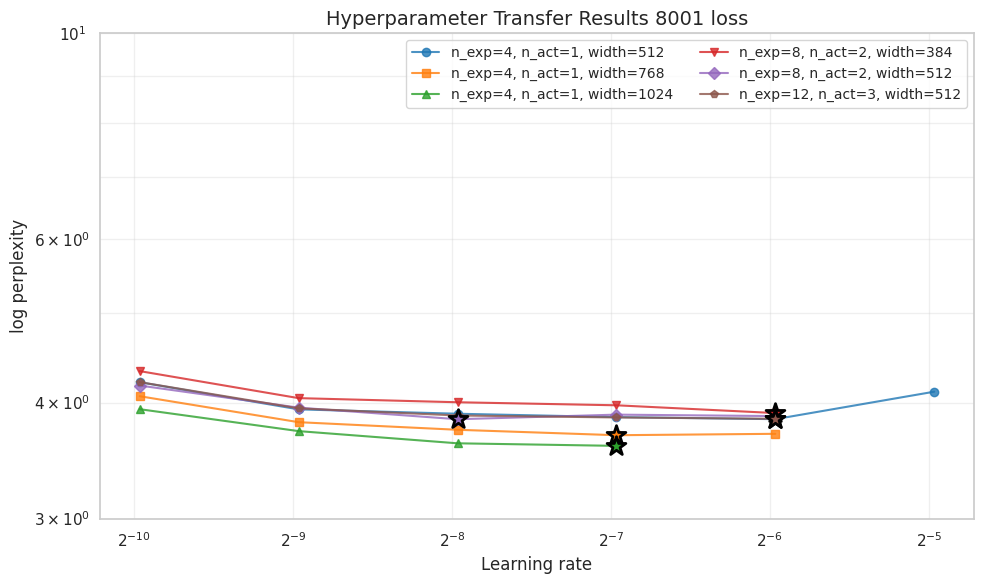

{(4, 768): [(0.001, np.float64(4.0639)),
  (0.002, np.float64(3.8104)),
  (0.004, np.float64(3.7392)),
  (0.008, np.float64(3.6891)),
  (0.016, np.float64(3.702))],
 (4, 512): [(0.001, np.float64(4.2078)),
  (0.002, np.float64(3.9335)),
  (0.004, np.float64(3.8911)),
  (0.008, np.float64(3.8587)),
  (0.016, np.float64(3.8391)),
  (0.032, np.float64(4.1099))],
 (8, 384): [(0.001, np.float64(4.3253)),
  (0.002, np.float64(4.0447)),
  (0.004, np.float64(4.0035)),
  (0.008, np.float64(3.9735)),
  (0.016, np.float64(3.8975))],
 (8, 512): [(0.001, np.float64(4.1731)),
  (0.002, np.float64(3.9504)),
  (0.004, np.float64(3.8384)),
  (0.008, np.float64(3.8824)),
  (0.016, np.float64(3.8684))],
 (12, 512): [(0.001, np.float64(4.2085)),
  (0.002, np.float64(3.9432)),
  (0.004, np.float64(3.8742)),
  (0.008, np.float64(3.8554)),
  (0.016, np.float64(3.8422))],
 (4, 1024): [(0.001, np.float64(3.9352)),
  (0.002, np.float64(3.7269)),
  (0.004, np.float64(3.6158)),
  (0.008, np.float64(3.5929))]}

In [26]:
result_8001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_8001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][8001]
                except:
                    print(f"never reached 8001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results(result_8001, title = "8001 loss")